In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys

sys.path.append('/home/hgf_hmgu/hgf_gib4562/tdmpc2')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from analysis.utils import reconstruct_cartpole_dmcontrol
from datetime import datetime

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed
# from common.trajectory_controller import TrajectoryController
# from common.activation_patcher import ActivationPatcher

#from analysis.utils import load_sweep_metadata, load_data

In [ ]:
# df_metadata = load_sweep_metadata(
#     ["logs/25-12-09-cartpole_initial_conditions_seeds_models"],
#     json_file_name="episode_metadata.json")
# df_metadata = df_metadata[df_metadata['checkpoint'] ==
#                           'ckpts/cartpole-swingup-3.pt']
# df = load_data(df_metadata,
#                cart_position=[0],
#                episode_file_name="episode_data.pkl")

# z = np.concatenate(df['latent_states'].tolist())
# actions = np.concatenate(df['actions'].tolist())
# observations = np.concatenate(df['observations'].tolist())
# rewards = np.concatenate(df['rewards'].tolist())

# z = torch.from_numpy(z).to('cuda')
# observations = torch.from_numpy(observations).to('cuda')
# actions = torch.from_numpy(actions).to('cuda')
# observations.shape, actions.shape, z.shape, rewards.shape

In [ ]:
import pickle
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/decoder.pkl',
        'rb') as f:
    decoder = pickle.load(f)


In [ ]:
# Base configuration
CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt'
#CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-noncentered.pt'
override_cfg = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,  # Disable video to speed up sweep
    record_planning=False,  # Focus on episode data
)

with initialize(config_path="tdmpc2", version_base=None):
    cfg = compose(config_name="config")
    OmegaConf.set_struct(cfg, False)
    cfg = OmegaConf.merge(cfg, override_cfg)

# Parse config
cfg = parse_cfg(cfg)
set_seed(cfg.seed)

cfg.initial_state = {
    'qpos': {
        'slider': 0,  #cart position
        'hinge_1': 0,  # pole angle
    },
}

env = make_env(cfg)

print("\nLoading agent...")
agent = TDMPC2(cfg)

# Optionally load checkpoint
if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
    print(f"Loading checkpoint: {cfg.checkpoint}")
    agent.load(cfg.checkpoint)


Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-3.pt


In [ ]:
def run_env_autonomous(env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    #env.reset()
    obs_list = []
    obs_list.append(obs)
    for _ in range(n_steps - 1):
        next_obs, reward, done, info = env.step(torch.tensor([0.0]))
        obs_list.append(next_obs)

    return np.array(obs_list)


@torch.no_grad()
def run_dynamics_model(agent, env, initial_state, n_steps=100):
    obs = env.reset(initial_state=initial_state)
    z = agent.model.encode(obs.to(agent.device), task=None)

    obs_list = []
    obs_list.append(obs)
    z_list = []
    z_list.append(z.cpu().numpy())
    for _ in range(n_steps - 1):
        #next_obs, *_ = env.step(torch.tensor([0.0]))

        z = agent.model.next(z, torch.tensor([0.0]).to(agent.device), task=None)
        z_list.append(z.cpu().numpy())
        #obs_list.append(next_obs)

    return np.array(z_list)


@torch.no_grad()
def run_dynamics_model_in_steps(agent, env, initial_state, n_steps=100, k=10):
    obs = env.reset(initial_state=initial_state)
    z = agent.model.encode(obs.to(agent.device), task=None)

    obs_list = []
    z_list = []
    obs_list.append(obs)
    z_list.append(z.cpu().numpy())
    for step in range(0, n_steps - 1, k):
        steps_in_chunk = min(k, n_steps - 1 - step)
        for _ in range(steps_in_chunk):

            next_obs, *_ = env.step(torch.tensor([0.0]))
            z = agent.model.next(z,
                                 torch.tensor([0.0]).to(agent.device),
                                 task=None)

            z_list.append(z.cpu().numpy())
            obs_list.append(next_obs)
        z = agent.model.encode(next_obs.to(agent.device), task=None)
        #z_list.append(z.cpu().numpy())
    return np.array(z_list), np.array(obs_list)

In [ ]:
# initial_state = {
#     'qpos': {
#         'slider': initial_position,  #cart position
#         'hinge_1': initial_angle_radians,  # pole angle
#     },
#     'qvel': {
#         'slider': 0,  #cart velocity
#         'hinge_1': 0,  # pole angular velocity
#     }
# }


In [224]:
intital_positions = [0]
initial_angles = np.linspace(0, 360, 11)
steps_to_run = 50
from itertools import product

results = {}
for initial_position, initial_angle in tqdm(
        product(intital_positions, initial_angles)):
    initial_angle_radians = np.radians(initial_angle)
    initial_state = {
        'qpos': {
            'slider': initial_position,  #cart position
            'hinge_1': initial_angle_radians,  # pole angle
        },
        'qvel': {
            'slider': 0,  #cart velocity
            'hinge_1': 0,  # pole angular velocity
        }
    }

    obs_true = run_env_autonomous(env, initial_state, steps_to_run)
    z_true = agent.model.encode(torch.from_numpy(obs_true).to(agent.device),
                                task=None).detach().cpu().numpy()

    z_predicted = run_dynamics_model(agent, env, initial_state, steps_to_run)
    obs_predicted = decoder.predict(z_predicted)

    dict_results_steps = {}
    for k in list(range(1, 10 + 1)) + [50]:
        z_predicted_steps, obs_true_steps = run_dynamics_model_in_steps(
            agent, env, initial_state, n_steps=steps_to_run, k=k)
        obs_predicted_steps = decoder.predict(z_predicted_steps)
        dict_results_steps[f'z_predicted_steps_{k}'] = z_predicted_steps
        #dict_results_steps[f'obs_true_steps_{k}'] = obs_true_steps
        dict_results_steps[f'obs_predicted_steps_{k}'] = obs_predicted_steps

    errors_latent = ((z_true - z_predicted)**2).mean(1)
    errors_physical = ((obs_true - obs_predicted)**2).mean(1)
    error_physical_per_dim = [
        ((obs_true[:, i] - obs_predicted[:, i])**2).mean() for i in range(5)
    ]
    error_latent_per_dim = [
        ((z_true[:, i] - z_predicted[:, i])**2).mean() for i in range(512)
    ]
    r2_physical = r2_score(obs_true, obs_predicted)
    r2_physical_per_dim = [
        r2_score(obs_true[:, i], obs_predicted[:, i]) for i in range(5)
    ]
    r2_latent = r2_score(z_true, z_predicted)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_predicted[:, i]) for i in range(512)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_predicted, axis=0)
    results[(initial_position, initial_angle)] = {
        'obs_true': obs_true,
        'obs_predicted': obs_predicted,
        'z_true': z_true,
        'z_predicted': z_predicted,
        **dict_results_steps,
        'errors_latent': errors_latent,
        'errors_physical': errors_physical,
        'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_physical': r2_physical,
        'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim,
    }

0it [00:00, ?it/s]

5it [00:02,  1.70it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/metrics/_regression.py:940: RuntimeWarning: overflow encountered in divide
  numerator[valid_score] / denominator[valid_score]
11it [00:06,  1.71it/s]


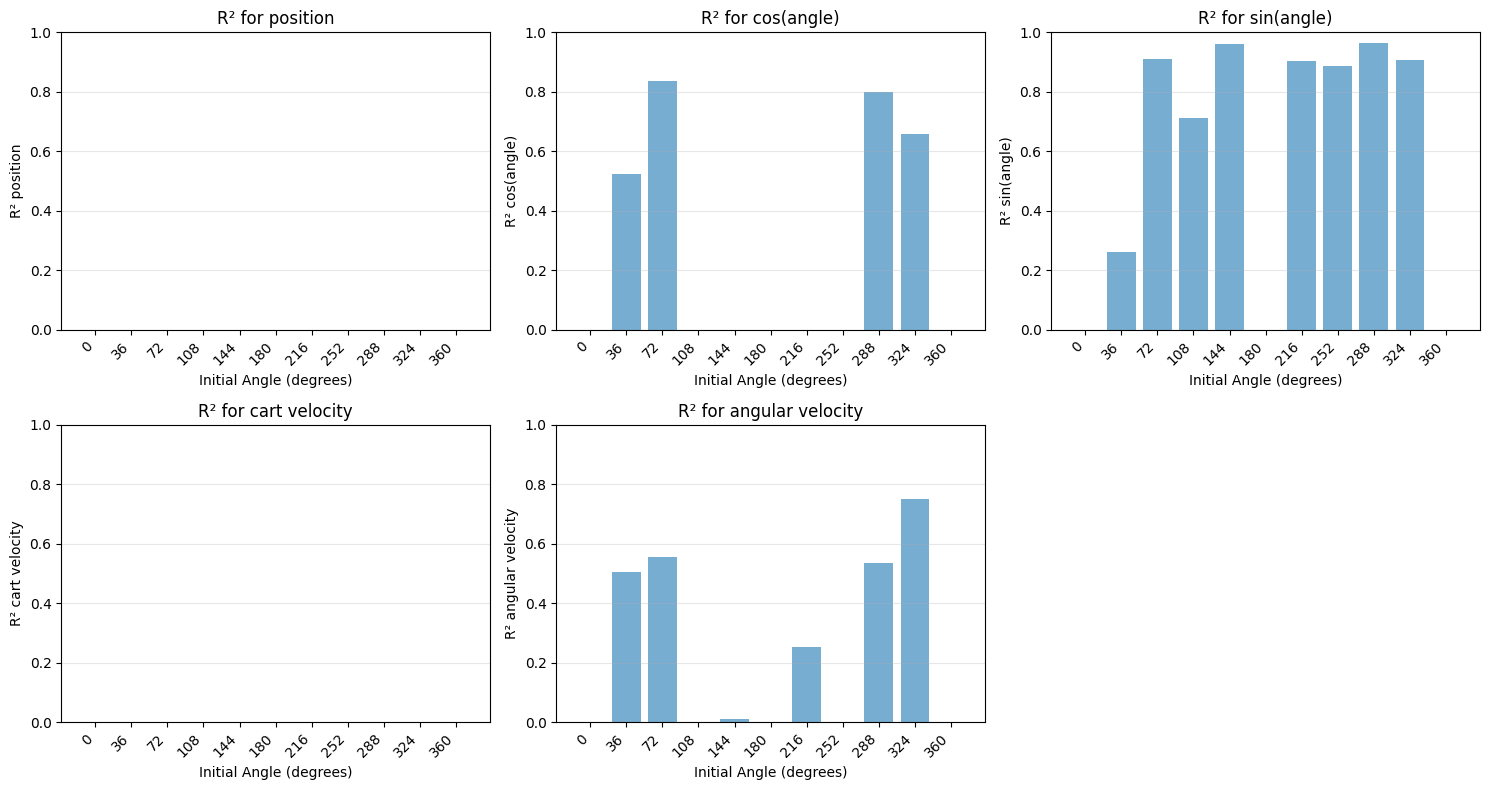

In [ ]:
# Plot R² physical per dimension for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    initial_angles_list = []
    r2_physical_per_dim_list = []

    for (initial_position, initial_angle), result in results.items():
        initial_angles_list.append(initial_angle)
        r2_physical_per_dim_list.append(result['r2_physical_per_dim'][dim])

    ax = axes[dim]
    ax.bar(range(len(initial_angles_list)), r2_physical_per_dim_list, alpha=0.6)
    ax.set_xlabel('Initial Angle (degrees)')
    ax.set_ylabel(f'R² {variable_names[dim]}')
    ax.set_ylim(0, 1)
    ax.set_title(f'R² for {variable_names[dim]}')
    ax.set_xticks(range(len(initial_angles_list)))
    ax.set_xticklabels([f'{angle:.0f}' for angle in initial_angles_list],
                       rotation=45,
                       ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


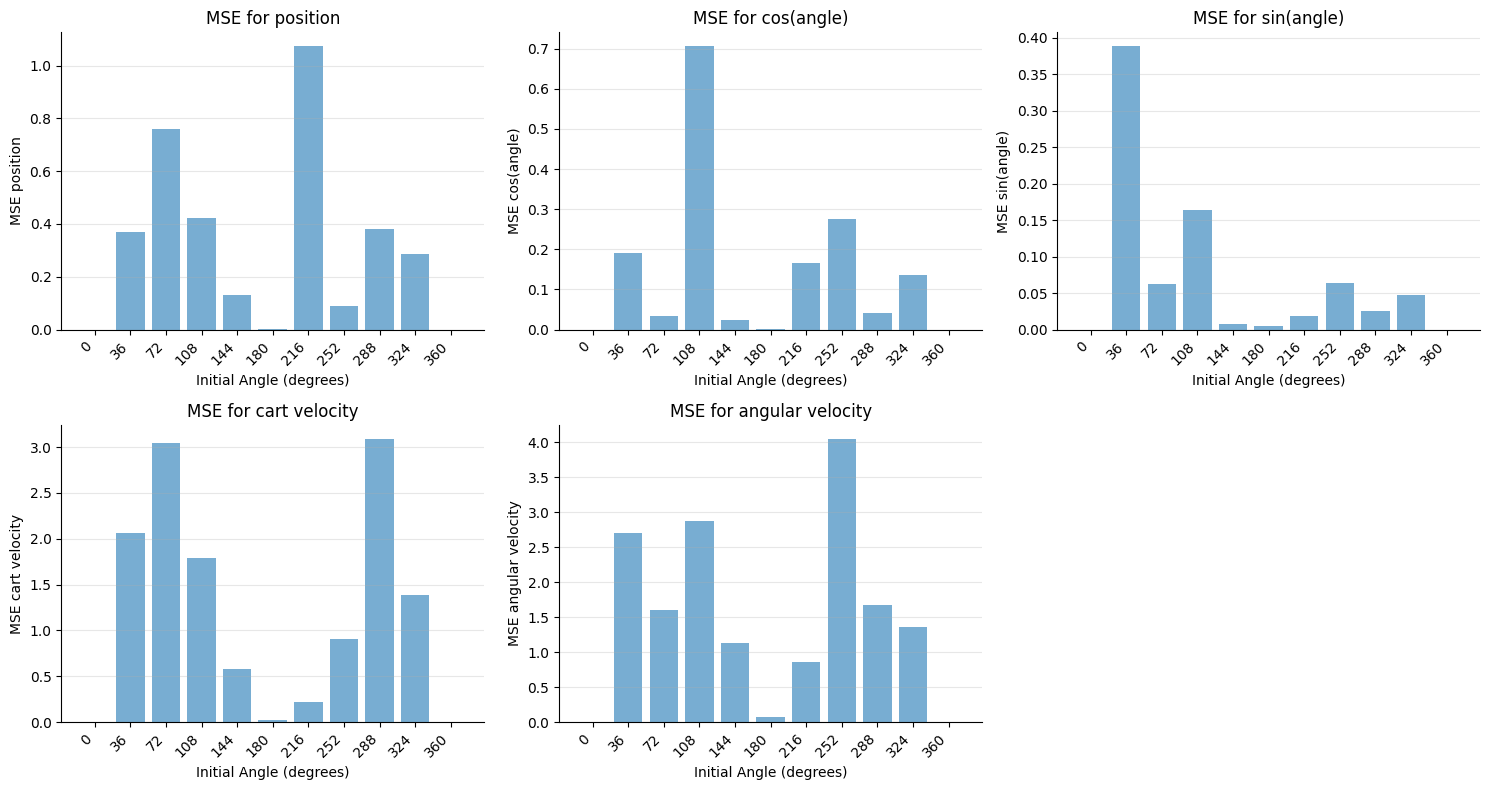

In [ ]:
# Plot R² physical per dimension for each initial condition
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    initial_angles_list = []
    r2_physical_per_dim_list = []

    for (initial_position, initial_angle), result in results.items():
        initial_angles_list.append(initial_angle)
        r2_physical_per_dim_list.append(result['error_physical_per_dim'][dim])

    ax = axes[dim]
    ax.bar(range(len(initial_angles_list)), r2_physical_per_dim_list, alpha=0.6)
    ax.set_xlabel('Initial Angle (degrees)')
    ax.set_ylabel(f'MSE {variable_names[dim]}')
    #ax.set_ylim(0, 1)
    ax.set_title(f'MSE for {variable_names[dim]}')
    ax.set_xticks(range(len(initial_angles_list)))
    ax.set_xticklabels([f'{angle:.0f}' for angle in initial_angles_list],
                       rotation=45,
                       ha='right')
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# ax1.plot(results[(0, 360)]['obs_true'])
# ax1.set_title('True Observations')
# ax2.plot(results[(0, 360)]['obs_predicted'])
# ax2.set_title('Predicted Observations')
# plt.tight_layout()
# plt.show()

In [ ]:
reconstruct_cartpole_dmcontrol(
    results[(0, 108)]['obs_true'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_true_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)


100%|██████████| 50/50 [00:01<00:00, 45.20it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_true_20251217_171719.mp4


In [ ]:
reconstruct_cartpole_dmcontrol(
    results[(0, 324)]['obs_predicted_steps'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_steps_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:01<00:00, 45.47it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_steps_20251217_172153.mp4


In [ ]:
obs_predicted_with_true_positions = results[(0, 108)]['obs_predicted']
obs_predicted_with_true_positions[:, 0] = results[(0, 108)]['obs_true'][:, 0]
reconstruct_cartpole_dmcontrol(
    #results[(0, 324)]['obs_predicted'],
    obs_predicted_with_true_positions,
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:01<00:00, 49.77it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20251217_165808.mp4


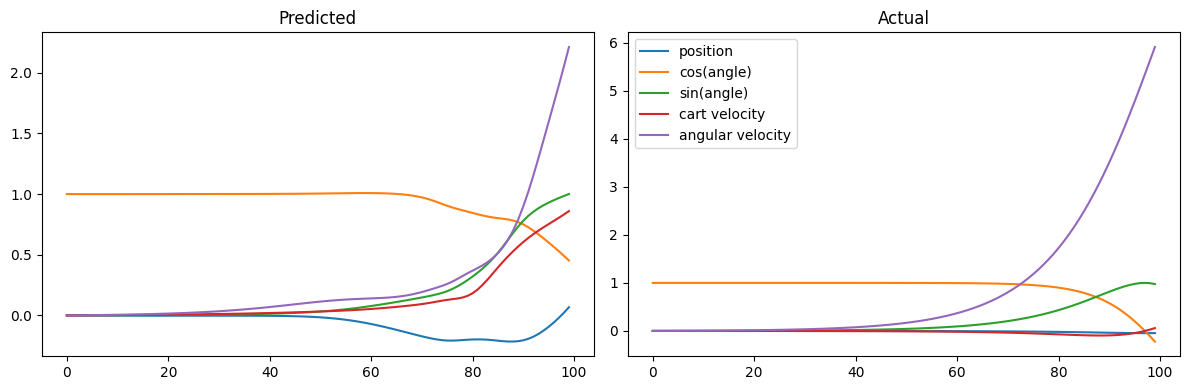

In [ ]:
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

steps_to_plot = 100
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for i in range(5):
    ax1.plot(obs_predicted[:steps_to_plot, i], label=variable_names[i])
ax1.set_title('Predicted')

for i in range(5):
    ax2.plot(obs_true[:steps_to_plot, i], label=variable_names[i])
ax2.set_title('Actual')
plt.legend()
plt.tight_layout()

In [ ]:
# errors_latent = ((z_true - z_predicted)**2).mean(1)
# errors_physical = ((obs_true - obs_predicted)**2).mean(1)

# r2_physical = r2_score(obs_true[:steps_to_plot], obs_predicted[:steps_to_plot])

# r2_physical_per_dim = [
#     r2_score(obs_true[:steps_to_plot, i], obs_predicted[:steps_to_plot, i])
#     for i in range(5)
# ]
# r2_latent = r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
# r2_latent_per_dim = [
#     r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
#     for i in range(512)
# ]

# variance_per_dim = np.var(z_true[:steps_to_plot], axis=0)

# r2_physical = r2_score(obs_true[:steps_to_plot], obs_predicted[:steps_to_plot])

# r2_physical_per_dim = [
#     r2_score(obs_true[:steps_to_plot, i], obs_predicted[:steps_to_plot, i])
#     for i in range(5)
# ]
# r2_latent = r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
# r2_latent_per_dim = [
#     r2_score(z_true[:steps_to_plot, i], z_predicted[:steps_to_plot, i])
#     for i in range(512)
# ]

# variance_per_dim = np.var(z_true[:steps_to_plot], axis=0)

# sorted_variance = sorted(variance_per_dim, reverse=True)

# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(sorted_variance, linewidth=2, color='steelblue', alpha=0.8)
# ax.set_xlabel('Latent Dimension (sorted by variance)', fontsize=12)
# ax.set_ylabel('Variance', fontsize=12)
# ax.set_title('Variance per Latent Dimension (Sorted)',
#              fontsize=14,
#              fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')
# plt.tight_layout()
# plt.show()

In [ ]:
# fig, ax = plt.subplots(figsize=(12, 5))

# # Sort R² scores by magnitude
# sorted_r2 = sorted(r2_latent_per_dim, reverse=True)

# ax.plot(sorted_r2, linewidth=2, color='steelblue', alpha=0.8)
# ax.set_ylim(0, 1)
# ax.set_xlabel('Latent Dimension (sorted by R²)', fontsize=12)
# ax.set_ylabel('R² Score', fontsize=12)
# ax.set_title('R² Score per Latent Dimension (Sorted)',
#              fontsize=14,
#              fontweight='bold')
# ax.grid(True, alpha=0.3, linestyle='--')

# # # Plot red dots at y=0 for dimensions with R² < 1
# # low_r2_count = sum(1 for r2 in sorted_r2 if r2 < 1)
# # if low_r2_count > 0:
# #     low_r2_indices = [i for i, r2 in enumerate(sorted_r2) if r2 < 1]
# #     ax.scatter(low_r2_indices, [0] * len(low_r2_indices),
# #                color='red',
# #                s=20,
# #                alpha=0.6,
# #                label=f'R² < 1 ({low_r2_count} dims)',
# #                zorder=5)
# #     ax.legend()

# plt.tight_layout()
# plt.show()

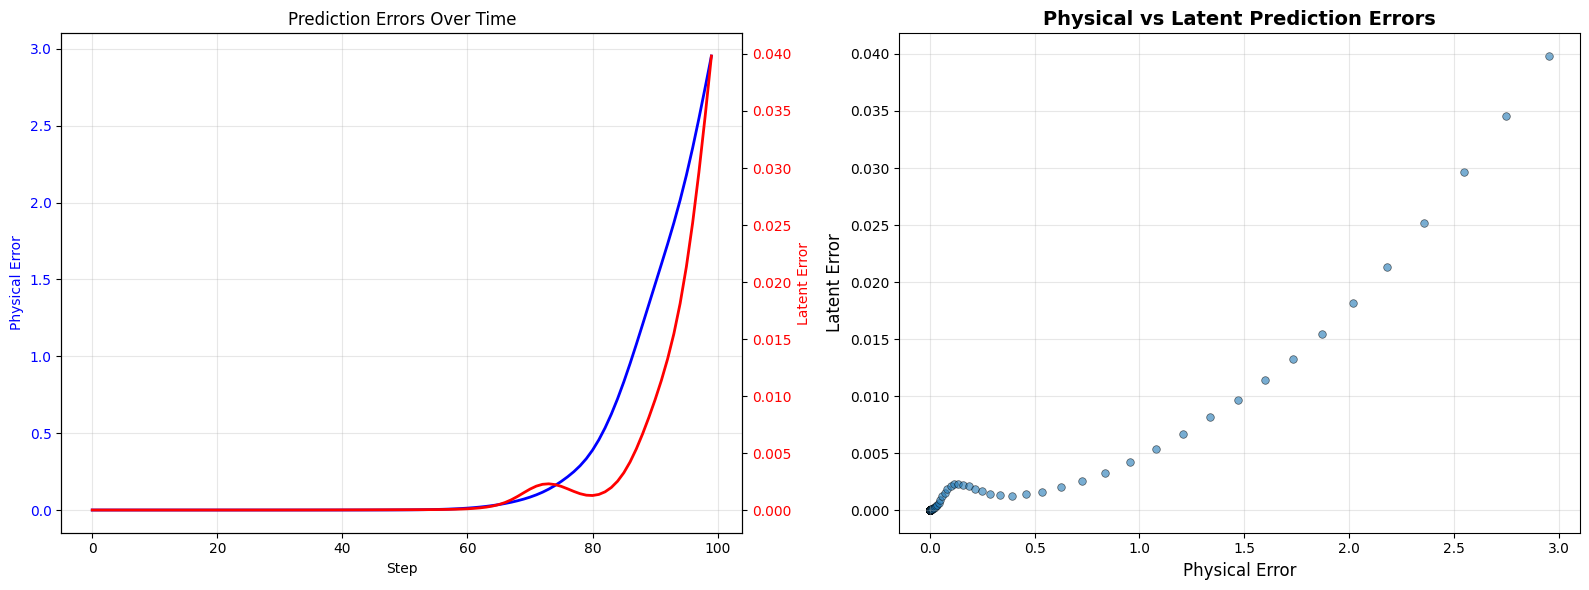

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Time series of errors with dual y-axes
ax1_left = ax1
ax1_left.plot(errors_physical, 'b-', label='Physical', linewidth=2)
ax1_left.set_xlabel('Step')
ax1_left.set_ylabel('Physical Error', color='b')
ax1_left.tick_params(axis='y', labelcolor='b')
ax1_left.grid(True, alpha=0.3)

# Create second y-axis for latent errors
ax1_right = ax1.twinx()
ax1_right.plot(errors_latent, 'r-', label='Latent', linewidth=2)
ax1_right.set_ylabel('Latent Error', color='r')
ax1_right.tick_params(axis='y', labelcolor='r')

ax1.set_title('Prediction Errors Over Time')

# Right plot: Scatter plot
ax2.scatter(errors_physical,
            errors_latent,
            alpha=0.6,
            s=30,
            edgecolors='k',
            linewidth=0.5)
ax2.set_xlabel('Physical Error', fontsize=12)
ax2.set_ylabel('Latent Error', fontsize=12)
ax2.set_title('Physical vs Latent Prediction Errors',
              fontsize=14,
              fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analysis of the dynamcis with predicted steps

In [225]:
# Store results for each prediction horizon
prediction_horizons = list(range(1, 10 + 1)) + [50]
metrics_by_horizon = {}

for horizon in prediction_horizons:
    z_pred = results[(0, 108)][f'z_predicted_steps_{horizon}']
    obs_pred = results[(0, 108)][f'obs_predicted_steps_{horizon}']
    obs_true = results[(0, 108)][f'obs_true']

    errors_latent = ((z_true - z_pred)**2).mean(1)
    errors_physical = ((obs_true - obs_pred)**2).mean(1)
    error_physical_per_dim = [
        ((obs_true[:, i] - obs_pred[:, i])**2).mean() for i in range(5)
    ]
    error_latent_per_dim = [
        ((z_true[:, i] - z_pred[:, i])**2).mean() for i in range(512)
    ]
    r2_physical = r2_score(obs_true, obs_pred)
    r2_physical_per_dim = [
        r2_score(obs_true[:, i], obs_pred[:, i]) for i in range(5)
    ]
    r2_latent = r2_score(z_true, z_pred)
    r2_latent_per_dim = [
        r2_score(z_true[:, i], z_pred[:, i]) for i in range(512)
    ]
    variance_z_true_per_dim = np.var(z_true, axis=0)
    variance_z_predicted_per_dim = np.var(z_pred, axis=0)

    metrics_by_horizon[horizon] = {
        'errors_latent': errors_latent,
        'errors_physical': errors_physical,
        'error_physical_per_dim': error_physical_per_dim,
        'error_latent_per_dim': error_latent_per_dim,
        'r2_physical': r2_physical,
        'r2_physical_per_dim': r2_physical_per_dim,
        'r2_latent': r2_latent,
        'r2_latent_per_dim': r2_latent_per_dim,
        'variance_z_true_per_dim': variance_z_true_per_dim,
        'variance_z_predicted_per_dim': variance_z_predicted_per_dim
    }

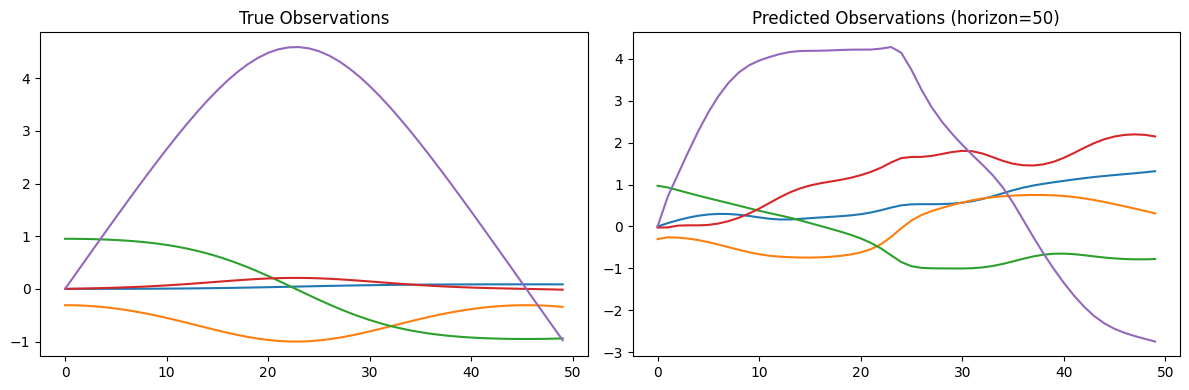

In [227]:
horizon = 50
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(obs_true)
axes[0].set_title('True Observations')
axes[1].plot(results[(0, 108)][f'obs_predicted_steps_{horizon}'])
axes[1].set_title(f'Predicted Observations (horizon={horizon})')
plt.tight_layout()

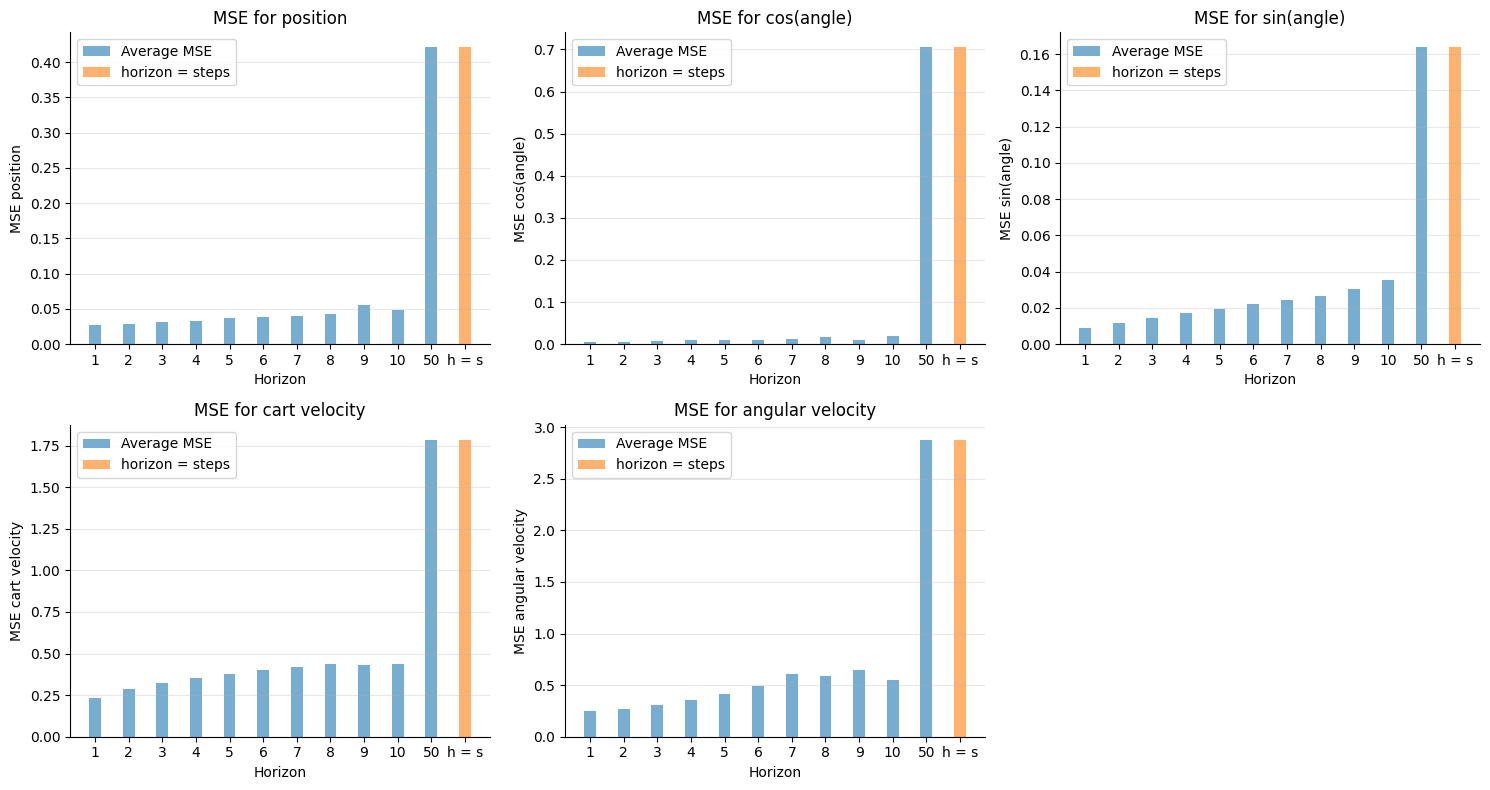

In [228]:
# Plot MSE as bar plot for each physical dimension
variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angular velocity'
}

# Use the same initial condition as in cell 24
initial_position = 0
initial_angle = 108

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for dim in range(5):
    horizons_list = []
    mse_per_horizon_list = []

    for horizon in prediction_horizons:
        horizons_list.append(horizon)
        mse_per_horizon_list.append(
            metrics_by_horizon[horizon]['error_physical_per_dim'][dim])

    ax = axes[dim]

    # Get the single trajectory error for this dimension
    single_trajectory_error = results[(0, 108)]['error_physical_per_dim'][dim]

    # Create bar positions
    x = np.arange(len(horizons_list))
    width = 0.35

    # Plot bars for average MSE
    ax.bar(x, mse_per_horizon_list, width, label='Average MSE', alpha=0.6)

    # Plot single bar for single trajectory to the right
    ax.bar(len(horizons_list),
           single_trajectory_error,
           width,
           label='horizon = steps',
           alpha=0.6)

    ax.set_xlabel('Horizon')
    ax.set_ylabel(f'MSE {variable_names[dim]}')
    ax.set_title(f'MSE for {variable_names[dim]}')
    ax.set_xticks(list(x) + [len(horizons_list)])
    ax.set_xticklabels(horizons_list + ['h = s'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# Hide the extra subplot
axes[5].axis('off')
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
horizon = 3
reconstruct_cartpole_dmcontrol(
    results[(0, 108)][f'obs_predicted_steps_{horizon}'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:01<00:00, 44.58it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20251217_174817.mp4


In [ ]:
horizon = 3
reconstruct_cartpole_dmcontrol(
    results[(0, 108)][f'obs_true'],
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:01<00:00, 45.23it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20251217_174832.mp4


In [ ]:
from scipy.ndimage import gaussian_filter1d

# Get the predicted observations
obs_predicted = results[(0, 108)][f'obs_predicted_steps_{horizon}']

# Apply Gaussian smoothing along the time axis (axis 0)
# Adjust sigma to control the amount of smoothing (higher = more smoothing)
sigma = 3.0
obs_predicted_smoothed = gaussian_filter1d(obs_predicted, sigma=sigma, axis=0)

obs_predicted_smoothed

horizon = 3
reconstruct_cartpole_dmcontrol(
    obs_predicted_smoothed,
    save_video=True,
    out_path=
    f'/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_{datetime.now().strftime("%Y%m%d_%H%M%S")}.mp4'
)

100%|██████████| 50/50 [00:01<00:00, 43.24it/s]


Wrote 50 frames to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/videos_autonomous/obs_predicted_20251217_175300.mp4
